# DeepLabV3 (ResNet-50) — LiTS Semantic Segmentation (Notebook 1 of 4)

**Course:** CSE 348 Digital Image Processing — Assignment Part 1  
**Group:** 01  
**Department of Computer Science and Engineering, East West University**

**Group members:**

| # | Name | Student ID |
|---|------|-----------|
| 1 | Md. Asif Hossain | 2022-3-60-007 |
| 2 | Nabil Subhan | 2022-3-60-063 |
| 3 | K M Nudar | 2022-3-60-234 |

Loads the **identical split** produced by NB0 → **Task E** (train ≥50 epochs) → **Task F** (test metrics) → **Task G** (error analysis).

- **Model:** `torchvision deeplabv3_resnet50`, COCO-pretrained; the DeepLab classifier + auxiliary heads are replaced for **3 classes** (bg/liver/tumor).
- **Input:** 2.5D — 3 channels = adjacent slices `[i−1, i, i+1]` (real volumetric context).
- **Loss:** Dice + light class-weighted CrossEntropy `[0.3, 1, 6]`; tumor-slice oversampling; best checkpoint by **validation tumor-F2**; horizontal-flip TTA at test.
- **Labels:** liver+tumor binary masks fused to `{0,1,2}` (tumor precedence), same as NB0.

> **Setup on Kaggle:** Accelerator = **GPU T4 ×2**, Internet = **ON**. **+ Add Input:** the LiTS dataset **and** the NB0-output dataset (contains `split.json`, `manifest.csv`).

In [1]:
# =====================================================================
# 1. Setup & imports (version pins)
# =====================================================================
import os, re, json, time, glob, random
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

print("torch", torch.__version__, "| albumentations", A.__version__)
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, "| GPUs:", torch.cuda.device_count())
WORK = Path("/kaggle/working"); WORK.mkdir(parents=True, exist_ok=True)

torch 2.10.0+cu128 | albumentations 2.0.8
device: cuda | GPUs: 2


## 2. Load the shared data split from NB0
Finds `split.json` under `/kaggle/input`, rebuilds the image/liver/tumor path lookups, and reconstructs the exact train/val/test slice lists. No re-splitting here — the split is fixed once in NB0.

In [2]:
# =====================================================================
# 2. Load split.json (produced & saved by NB0)  + rebuild path lookups
# =====================================================================
cand = glob.glob("/kaggle/input/**/split.json", recursive=True)
assert cand, "split.json not found -> + Add Input the NB0-output dataset."
SPLIT_PATH = cand[0]
meta = json.load(open(SPLIT_PATH))
CLASS_NAMES = meta["class_names"]; NUM_CLASSES = meta["num_classes"]; IMG_SIZE = 256
class_weights = torch.tensor(meta["class_weights"], dtype=torch.float32)
print("loaded:", SPLIT_PATH, "| seed", meta["seed"], "| filter_to_liver", meta["filter_to_liver"])
print("class weights [bg,liver,tumor]:", meta["class_weights"])

IMG_DIR, LIVER_DIR, TUMOR_DIR = (Path(meta["dirs"][k]) for k in ("images","liver","tumor"))
if not IMG_DIR.exists():                      # fallback: re-detect if mount path differs
    root = next(iter(glob.glob("/kaggle/input/**/Thesis_data", recursive=True)), None)
    root = Path(root)
    IMG_DIR   = next(p for p in root.iterdir() if p.is_dir() and "image" in p.name.lower())
    LIVER_DIR = next(p for p in root.iterdir() if p.is_dir() and "liver" in p.name.lower())
    TUMOR_DIR = next(p for p in root.iterdir() if p.is_dir() and "tumor" in p.name.lower())

def vskey(p):
    n = [int(x) for x in re.findall(r"\d+", Path(p).stem)]
    return (n[0], n[1]) if len(n) >= 2 else (n[0], -1)
img_by = {vskey(p): p for p in IMG_DIR.glob("*.png")}
liv_by = {vskey(p): p for p in LIVER_DIR.glob("*.png")}
tum_by = {vskey(p): p for p in TUMOR_DIR.glob("*.png")}
split = meta["slices"]
print("slices  train/val/test:", {k: len(v) for k, v in split.items()})

loaded: /kaggle/input/datasets/sabuktagin/nb0-lits-2d-semantic-segmentation-data/split.json | seed 42 | filter_to_liver True
class weights [bg,liver,tumor]: [0.0708, 1.0, 16.4712]
slices  train/val/test: {'train': 13447, 'val': 2553, 'test': 3158}


## 3. Dataset & augmentation (identical to NB0)
`LiTSDataset` fuses the two binary masks into a class-index label and applies the NB0 augmentation pipeline (train only). Validation/test use normalize-only.

In [3]:
# =====================================================================
# 3. Dataset + augmentation (same pipeline as NB0)
# =====================================================================
IMAGENET_MEAN = (0.485, 0.456, 0.406); IMAGENET_STD = (0.229, 0.224, 0.225)
# Run-A augmentation: flips RESTORED (regularization dominates for this small dataset;
# your own ablation showed flips help). ElasticTransform fixed to a real deformation.
train_tf = A.Compose([
    A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5),
    A.Affine(scale=(0.9,1.1), translate_percent=0.06, rotate=(-15,15), p=0.5),
    A.OneOf([A.ElasticTransform(alpha=40, sigma=6),
             A.GridDistortion(num_steps=5, distort_limit=0.2)], p=0.25),
    A.RandomBrightnessContrast(0.2, 0.2, p=0.3),
    A.GaussNoise(p=0.2),
    A.Normalize(IMAGENET_MEAN, IMAGENET_STD), ToTensorV2(),
])
eval_tf = A.Compose([A.Normalize(IMAGENET_MEAN, IMAGENET_STD), ToTensorV2()])

# 2.5D INPUT: 3 channels = adjacent slices [i-1, i, i+1] (real volumetric context,
# instead of replicating one gray slice). Neighbors clamp to center at volume ends.
def load_25d(vol, sl):
    center = np.array(Image.open(img_by[(vol, sl)]).convert("L"))
    prev = img_by.get((vol, sl-1)); nxt = img_by.get((vol, sl+1))
    p = np.array(Image.open(prev).convert("L")) if prev is not None else center
    n = np.array(Image.open(nxt).convert("L")) if nxt is not None else center
    return np.stack([p, center, n], axis=-1)

class LiTSDataset(Dataset):
    def __init__(self, ids, tf):
        self.ids = [tuple(int(x) for x in s.split("_")) for s in ids]; self.tf = tf
    def __len__(self): return len(self.ids)
    def __getitem__(self, i):
        vol, sl = self.ids[i]
        img = load_25d(vol, sl)
        liv = np.array(Image.open(liv_by[(vol,sl)]).convert("L")) > 0
        tum = np.array(Image.open(tum_by[(vol,sl)]).convert("L")) > 0
        lab = np.zeros((IMG_SIZE, IMG_SIZE), np.uint8); lab[liv]=1; lab[tum]=2
        out = self.tf(image=img, mask=lab)
        return out["image"], out["mask"].long(), f"{vol}_{sl}"

train_ds = LiTSDataset(split["train"], train_tf)
val_ds   = LiTSDataset(split["val"],   eval_tf)
test_ds  = LiTSDataset(split["test"],  eval_tf)
print("datasets (2.5D input):", len(train_ds), len(val_ds), len(test_ds))

datasets (2.5D input): 13447 2553 3158


## 4. Model — DeepLabV3-ResNet50
COCO-pretrained backbone; the DeepLab classifier head and the auxiliary FCN head are both replaced with a `1x1` conv projecting to **3 classes**. The ASPP module (atrous spatial pyramid pooling) is kept — it captures multi-scale context, which helps segment livers/tumors of very different sizes.

In [4]:
# =====================================================================
# 4. DeepLabV3-ResNet50: load COCO weights, swap heads -> 3 classes
# =====================================================================
model = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.DEFAULT, aux_loss=True)
model.classifier[-1]     = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
model.aux_classifier[-1] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
model = model.to(device)
n_params = sum(p.numel() for p in model.parameters())/1e6
print(f"DeepLabV3-ResNet50 ready | params: {n_params:.1f}M | classes: {NUM_CLASSES}")

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 220MB/s]


DeepLabV3-ResNet50 ready | params: 42.0M | classes: 3


## 5. Training configuration (all hyperparameters in one cell)

In [5]:
# =====================================================================
# 5. CONFIG — single source of truth (reported for viva)
# =====================================================================
CONFIG = {
    "model": "DeepLabV3-ResNet50 (COCO pretrained), 2.5D input",
    "num_classes": NUM_CLASSES, "img_size": IMG_SIZE,
    "epochs": 50, "batch_size": 16, "num_workers": 2,
    "optimizer": "AdamW", "lr": 1e-4, "weight_decay": 1e-2,   # unified across both models
    "scheduler": "LinearWarmup(3) -> CosineAnnealing",
    "loss": "Dice + class-weighted CE [0.3,1,6] (+0.4*aux)",
    "sampler": "WeightedRandomSampler (tumor slices 4x)",
    "checkpoint_metric": "val tumor F2 (recall-weighted)",
    "ce_weights": [0.3, 1.0, 6.0], "amp": device.type == "cuda",
}
CONFIG


{'model': 'DeepLabV3-ResNet50 (COCO pretrained), 2.5D input',
 'num_classes': 3,
 'img_size': 256,
 'epochs': 50,
 'batch_size': 16,
 'num_workers': 2,
 'optimizer': 'AdamW',
 'lr': 0.0001,
 'weight_decay': 0.01,
 'scheduler': 'LinearWarmup(3) -> CosineAnnealing',
 'loss': 'Dice + class-weighted CE [0.3,1,6] (+0.4*aux)',
 'sampler': 'WeightedRandomSampler (tumor slices 4x)',
 'checkpoint_metric': 'val tumor F2 (recall-weighted)',
 'ce_weights': [0.3, 1.0, 6.0],
 'amp': True}

In [6]:
# dataloaders (built from CONFIG)
# tumor-slice oversampling: WeightedRandomSampler raises tumor prevalence per batch (~12% -> ~45%)
import glob as _glob
_mp = next(iter(_glob.glob("/kaggle/input/**/manifest.csv", recursive=True)), None)
if _mp:
    _mdf = pd.read_csv(_mp); _ht = {f"{r.volume}_{r.slice}": int(r.has_tumor) for r in _mdf.itertuples()}
    has_tumor = np.array([_ht.get(s, 0) for s in split["train"]])
else:
    has_tumor = np.array([int((np.array(Image.open(tum_by[tuple(int(x) for x in s.split('_'))]).convert('L'))>0).any())
                          for s in split["train"]])
_w = np.where(has_tumor == 1, 4.0, 1.0)
sampler = torch.utils.data.WeightedRandomSampler(torch.as_tensor(_w, dtype=torch.double), len(_w), replacement=True)
print(f"tumor-positive train slices: {int(has_tumor.sum())}/{len(has_tumor)} -> oversampled 4x")

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler,
                          num_workers=CONFIG["num_workers"], pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG["batch_size"], shuffle=False,
                          num_workers=CONFIG["num_workers"], pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG["batch_size"], shuffle=False,
                          num_workers=CONFIG["num_workers"], pin_memory=True)
print("batches  train/val/test:", len(train_loader), len(val_loader), len(test_loader))

tumor-positive train slices: 5186/13447 -> oversampled 4x
batches  train/val/test: 840 160 198


## 6. Loss & metrics
- **Loss:** `Dice + weighted CE`. Dice is imbalance-robust; the CE class weights push the tiny tumor class.
- **Metrics (Task F):** a single pixel-level **confusion matrix** is the source of truth for mIoU, per-class IoU, overall & mean pixel accuracy, and Dice — the same code is reused in NB2/NB3 for a fair comparison.

In [7]:
# =====================================================================
# 6. Loss (Dice + weighted CE) and confusion-matrix metrics
# =====================================================================
ce = nn.CrossEntropyLoss(weight=torch.tensor(CONFIG["ce_weights"], device=device))  # light [0.3,1,6]
def dice_loss(logits, target, eps=1.0):
    p  = torch.softmax(logits, 1)
    oh = F.one_hot(target, NUM_CLASSES).permute(0, 3, 1, 2).float()
    dims = (0, 2, 3)
    tp = (p*oh).sum(dims); fp = (p*(1-oh)).sum(dims); fn = (oh*(1-p)).sum(dims)
    return (1 - (2*tp + eps)/(2*tp + fp + fn + eps)).mean()
def criterion(logits, target): return ce(logits, target) + dice_loss(logits, target)

def tumor_f2_from_cm(cm):   # F2 weights recall 4x precision (clinical: don't miss tumor)
    m = cm.mat.double(); tp = m[2,2]; fp = m[:,2].sum()-tp; fn = m[2,:].sum()-tp
    rec = (tp/(tp+fn).clamp(min=1e-9)).item(); prec = (tp/(tp+fp).clamp(min=1e-9)).item()
    return 5*prec*rec/(4*prec+rec+1e-9), rec, prec

class ConfMat:
    def __init__(self, n): self.n = n; self.mat = torch.zeros(n, n, dtype=torch.int64)
    def update(self, pred, tgt):
        k = (tgt >= 0) & (tgt < self.n)
        idx = self.n * tgt[k].to(torch.int64) + pred[k].to(torch.int64)
        self.mat += torch.bincount(idx, minlength=self.n**2).reshape(self.n, self.n)
    def compute(self):
        m = self.mat.double(); tp = m.diag(); fp = m.sum(0)-tp; fn = m.sum(1)-tp
        iou  = tp / (tp+fp+fn).clamp(min=1e-9)
        dice = 2*tp / (2*tp+fp+fn).clamp(min=1e-9)
        recall = tp / m.sum(1).clamp(min=1e-9)
        return {"iou": iou.tolist(), "miou": iou.mean().item(),
                "dice": dice.tolist(), "mdice": dice.mean().item(),
                "pixel_acc": (tp.sum()/m.sum().clamp(min=1e-9)).item(),
                "mean_pixel_acc": recall.mean().item()}
print("loss + metrics ready")

loss + metrics ready


## 7. Training loop (Task E) — per-epoch loss + validation mIoU

  ep1 it200/840 loss 1.558
  ep1 it400/840 loss 1.230
  ep1 it600/840 loss 1.147
  ep1 it800/840 loss 1.101
epoch 01/50 | train 1.400 | val 0.724 | mIoU 0.7276 | tumorF2 0.6964 (R 0.811 P 0.444)
  ep2 it200/840 loss 0.769
  ep2 it400/840 loss 0.547
  ep2 it600/840 loss 0.598
  ep2 it800/840 loss 0.542
epoch 02/50 | train 0.669 | val 0.426 | mIoU 0.8132 | tumorF2 0.7842 (R 0.833 P 0.634)
  ep3 it200/840 loss 0.356
  ep3 it400/840 loss 0.269
  ep3 it600/840 loss 0.332
  ep3 it800/840 loss 0.273
epoch 03/50 | train 0.327 | val 0.377 | mIoU 0.8211 | tumorF2 0.7553 (R 0.762 P 0.728)
  ep4 it200/840 loss 0.281
  ep4 it400/840 loss 0.232
  ep4 it600/840 loss 0.218
  ep4 it800/840 loss 0.327
epoch 04/50 | train 0.252 | val 0.375 | mIoU 0.8227 | tumorF2 0.7767 (R 0.786 P 0.741)
  ep5 it200/840 loss 0.257
  ep5 it400/840 loss 0.171
  ep5 it600/840 loss 0.219
  ep5 it800/840 loss 0.192
epoch 05/50 | train 0.217 | val 0.337 | mIoU 0.8399 | tumorF2 0.8021 (R 0.831 P 0.703)
  ep6 it200/840 loss 0.26

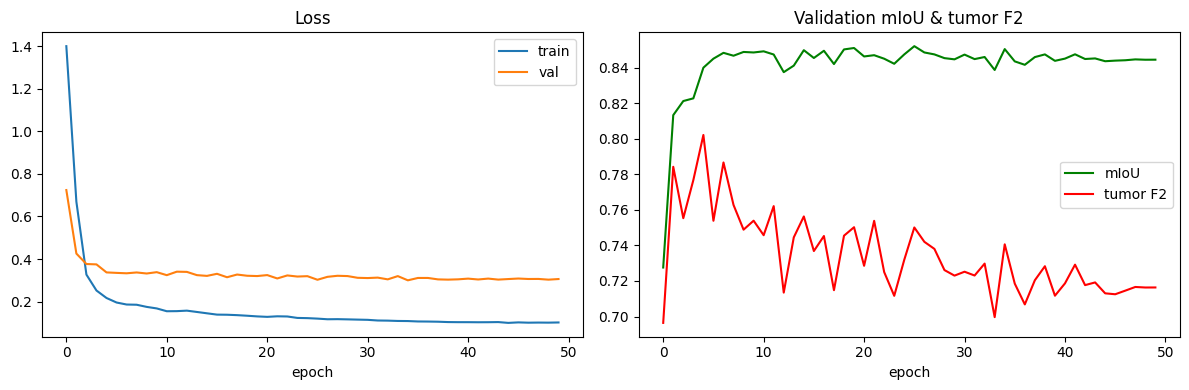

In [8]:
# =====================================================================
# 7. Train >=50 epochs with AMP; track best val mIoU; plot curves
# =====================================================================
opt = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
warmup = 3
sched = torch.optim.lr_scheduler.SequentialLR(opt, [
    torch.optim.lr_scheduler.LinearLR(opt, 0.1, 1.0, total_iters=warmup),
    torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CONFIG["epochs"]-warmup)],
    milestones=[warmup])
scaler = torch.amp.GradScaler(enabled=CONFIG["amp"])

def run_eval(loader):
    model.eval(); cm = ConfMat(NUM_CLASSES); vloss = 0.0
    with torch.no_grad():
        for x, y, _ in loader:
            x, y = x.to(device), y.to(device)
            with torch.amp.autocast(device.type, enabled=CONFIG["amp"]):
                out = model(x)["out"]; vloss += criterion(out, y).item()
            cm.update(out.argmax(1).cpu(), y.cpu())
    return vloss/len(loader), cm.compute(), cm

hist = {"train_loss": [], "val_loss": [], "val_miou": [], "val_tumor_f2": []}
best_f2, best_miou, t0 = -1.0, -1.0, time.time()
for ep in range(1, CONFIG["epochs"]+1):
    model.train(); tl = 0.0
    for bi, (x, y, _) in enumerate(train_loader):
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        with torch.amp.autocast(device.type, enabled=CONFIG["amp"]):
            out = model(x)
            loss = criterion(out["out"], y) + 0.4*criterion(out["aux"], y)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        tl += loss.item()
        if (bi+1) % 200 == 0: print(f"  ep{ep} it{bi+1}/{len(train_loader)} loss {loss.item():.3f}")
    sched.step()
    vloss, vm, vcm = run_eval(val_loader)
    f2, rec, prec = tumor_f2_from_cm(vcm)
    hist["train_loss"].append(tl/len(train_loader)); hist["val_loss"].append(vloss)
    hist["val_miou"].append(vm["miou"]); hist["val_tumor_f2"].append(f2)
    best_miou = max(best_miou, vm["miou"])
    print(f"epoch {ep:02d}/{CONFIG['epochs']} | train {tl/len(train_loader):.3f} | val {vloss:.3f} | "
          f"mIoU {vm['miou']:.4f} | tumorF2 {f2:.4f} (R {rec:.3f} P {prec:.3f})")
    if f2 > best_f2:                               # SELECT BY TUMOR F2 (recall-weighted)
        best_f2 = f2; torch.save(model.state_dict(), WORK/"deeplabv3_best.pt")
train_time = time.time()-t0
print(f"\nDONE in {train_time/60:.1f} min | best val tumor F2 {best_f2:.4f} | best val mIoU {best_miou:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist["train_loss"], label="train"); ax[0].plot(hist["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(hist["val_miou"], color="green", label="mIoU"); ax[1].plot(hist["val_tumor_f2"], color="red", label="tumor F2")
ax[1].set_title("Validation mIoU & tumor F2"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.savefig(WORK/"deeplabv3_curves.png", dpi=120); plt.show()

## 8. Test-set evaluation (Task F)
Loads the best checkpoint and reports **mIoU, per-class IoU, overall & mean pixel accuracy, Dice**, and the **pixel-level confusion matrix** on the held-out test volumes (never seen in training/validation).

=== DeepLabV3 — TEST metrics ===
     class    IoU   Dice
background 0.9938 0.9969
     liver 0.9035 0.9493
     tumor 0.4067 0.5782

mIoU 0.7680 | mean Dice 0.8415 | pixel acc 0.9925 | mean pixel acc 0.8049

--- CLINICAL METRICS (medical-grade) ---
tumor sensitivity (recall) : 0.4509   (miss rate 54.9%)  <- key clinical number
liver sensitivity (recall) : 0.9676
per-patient liver Dice     : 0.9469 +/- 0.0331  (n=19 volumes)
per-patient tumor Dice     : 0.4715 +/- 0.2983  (n=16 volumes)


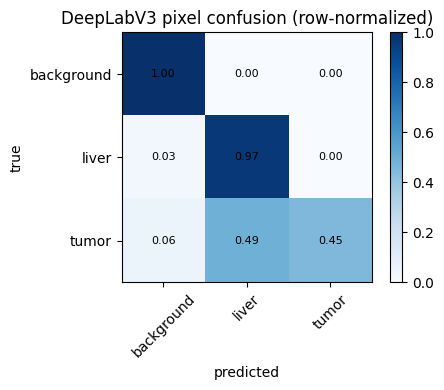

In [9]:
# =====================================================================
# 8. Task F — held-out test metrics + confusion matrix
# =====================================================================
from collections import defaultdict
model.load_state_dict(torch.load(WORK/"deeplabv3_best.pt", map_location=device))

def tta_pred(x):   # horizontal-flip test-time augmentation (free recall/Dice bump)
    with torch.amp.autocast(device.type, enabled=CONFIG["amp"]):
        o1 = model(x)["out"].softmax(1)
        o2 = torch.flip(model(torch.flip(x, dims=[3]))["out"].softmax(1), dims=[3])
    return (o1 + o2).argmax(1).cpu()

cmref = ConfMat(NUM_CLASSES); vol_cms = defaultdict(lambda: ConfMat(NUM_CLASSES))
model.eval()
with torch.no_grad():
    for x, y, keys in test_loader:
        p = tta_pred(x.to(device))
        cmref.update(p, y)
        for b, key in enumerate(keys):
            vol_cms[int(key.split("_")[0])].update(p[b], y[b])
testm = cmref.compute()

# ---- clinical metrics (medical-grade): sensitivity + per-PATIENT Dice ----
def _dice_c(cm, c):
    m=cm.mat.double(); tp=m[c,c]; fp=m[:,c].sum()-tp; fn=m[c,:].sum()-tp
    return (2*tp/(2*tp+fp+fn).clamp(min=1e-9)).item()
def _sens_c(cm, c):
    m=cm.mat.double(); tp=m[c,c]; fn=m[c,:].sum()-tp
    return (tp/(tp+fn).clamp(min=1e-9)).item()
tumor_sens=_sens_c(cmref,2); liver_sens=_sens_c(cmref,1)
liver_vd=[_dice_c(cm,1) for cm in vol_cms.values() if cm.mat[1,:].sum()>0]
tumor_vd=[_dice_c(cm,2) for cm in vol_cms.values() if cm.mat[2,:].sum()>0]
pv_liver=(float(np.mean(liver_vd)), float(np.std(liver_vd)))
pv_tumor=(float(np.mean(tumor_vd)), float(np.std(tumor_vd)))

print("=== DeepLabV3 — TEST metrics ===")
tbl = pd.DataFrame({"class": CLASS_NAMES,
                    "IoU": np.round(testm["iou"], 4),
                    "Dice": np.round(testm["dice"], 4)})
print(tbl.to_string(index=False))
print(f"\nmIoU {testm['miou']:.4f} | mean Dice {testm['mdice']:.4f} | "
      f"pixel acc {testm['pixel_acc']:.4f} | mean pixel acc {testm['mean_pixel_acc']:.4f}")
print("\n--- CLINICAL METRICS (medical-grade) ---")
print(f"tumor sensitivity (recall) : {tumor_sens:.4f}   (miss rate {1-tumor_sens:.1%})  <- key clinical number")
print(f"liver sensitivity (recall) : {liver_sens:.4f}")
print(f"per-patient liver Dice     : {pv_liver[0]:.4f} +/- {pv_liver[1]:.4f}  (n={len(liver_vd)} volumes)")
print(f"per-patient tumor Dice     : {pv_tumor[0]:.4f} +/- {pv_tumor[1]:.4f}  (n={len(tumor_vd)} volumes)")

cmn = cmref.mat.double(); cmn = (cmn / cmn.sum(1, keepdim=True).clamp(min=1e-9)).numpy()
plt.figure(figsize=(5,4)); plt.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
plt.xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45); plt.yticks(range(NUM_CLASSES), CLASS_NAMES)
plt.xlabel("predicted"); plt.ylabel("true"); plt.title("DeepLabV3 pixel confusion (row-normalized)")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES): plt.text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(); plt.tight_layout(); plt.savefig(WORK/"deeplabv3_confusion.png", dpi=120); plt.show()

## 9. Error analysis (Task G)
Worst-performing test slices by per-image IoU (prediction vs. ground truth side-by-side) and the most-confused class pair read off the confusion matrix.

**Hypotheses (to confirm against the outputs below):**
- **Tumor is expected to be the hardest class** — it is only ~0.4% of pixels even after filtering, lesions are tiny and low-contrast, and boundaries are ambiguous on CT.
- **Tumor <-> liver confusion** is likely the dominant error: tumors sit *inside* the liver, are small, and share intensity ranges, so the model tends to label lesion pixels as liver.
- **Liver <-> background errors** concentrate at organ boundaries and on slices where only a sliver of liver enters/exits the axial plane.
- Worst-IoU slices are expected to be **tumor-bearing or liver-edge slices**; the printed most-confused pair below quantifies which error actually dominates.

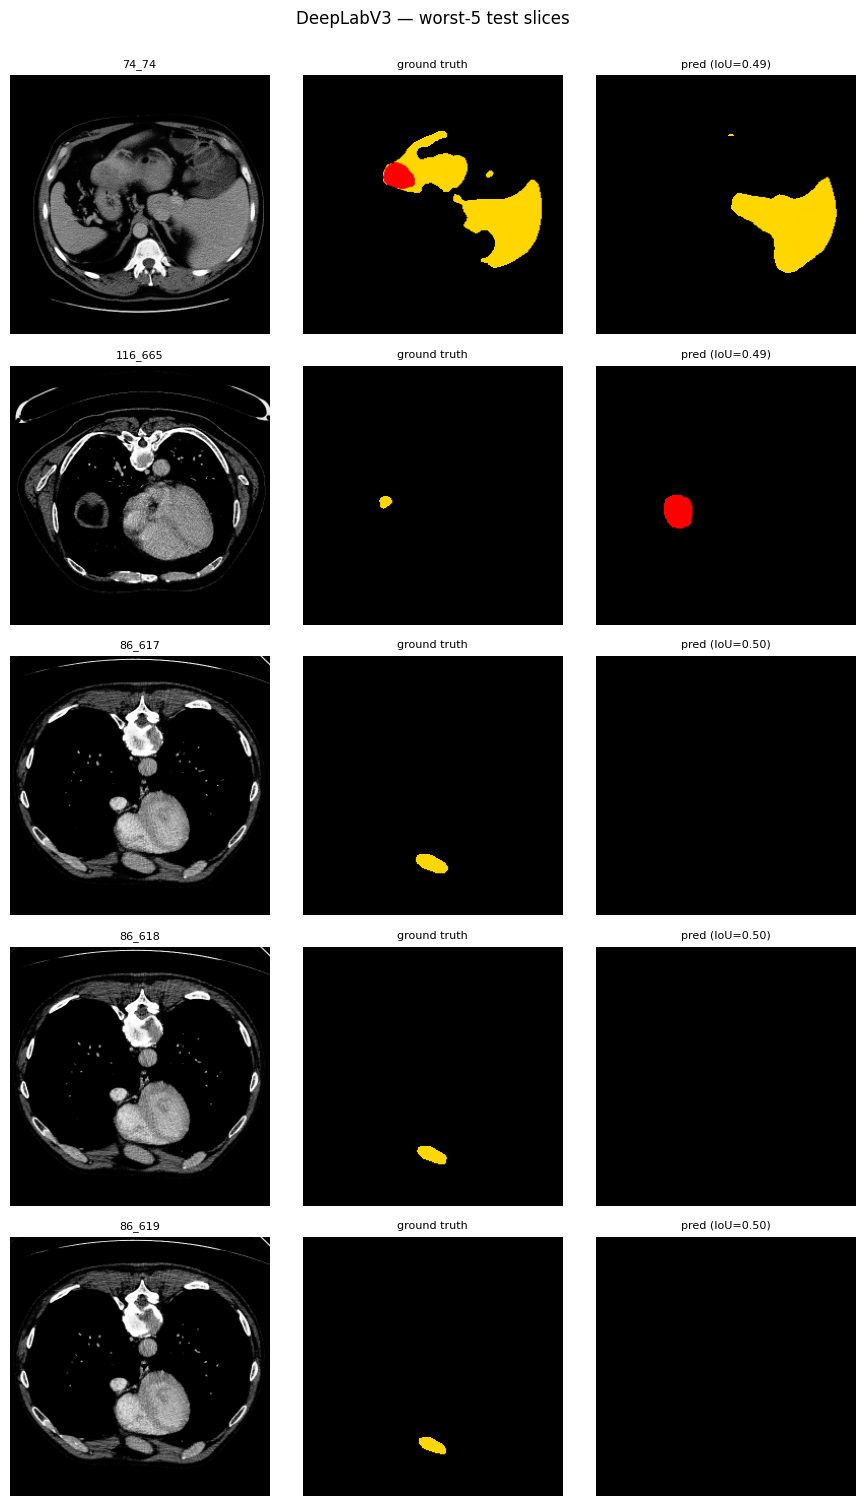

most-confused class pair: TRUE 'background' -> PRED 'liver' (725133 px)


In [10]:
# =====================================================================
# 9. Task G — worst test images + most-confused class pair
# =====================================================================
def image_iou(pred, tgt):
    ious = []
    for c in range(NUM_CLASSES):
        ti = tgt == c
        if ti.sum() == 0: continue
        pi = pred == c
        inter = (pi & ti).sum().item(); union = (pi | ti).sum().item()
        ious.append(inter/union if union else 0.0)
    return float(np.mean(ious)) if ious else 1.0

scores = []
model.eval()
with torch.no_grad():
    for i in range(len(test_ds)):
        x, y, key = test_ds[i]
        with torch.amp.autocast(device.type, enabled=CONFIG["amp"]):
            p = model(x.unsqueeze(0).to(device))["out"].argmax(1)[0].cpu()
        scores.append((image_iou(p, y), key, p, y))
scores.sort(key=lambda t: t[0])

cmap = plt.matplotlib.colors.ListedColormap(["black","gold","red"])
worst = scores[:5]
fig, ax = plt.subplots(len(worst), 3, figsize=(9, 3*len(worst)))
for i, (sc, key, p, y) in enumerate(worst):
    k = tuple(int(v) for v in key.split("_")); im = np.array(Image.open(img_by[k]).convert("L"))
    ax[i,0].imshow(im, cmap="gray"); ax[i,0].set_title(f"{key}", fontsize=8)
    ax[i,1].imshow(y.numpy(), cmap=cmap, vmin=0, vmax=2); ax[i,1].set_title("ground truth", fontsize=8)
    ax[i,2].imshow(p.numpy(), cmap=cmap, vmin=0, vmax=2); ax[i,2].set_title(f"pred (IoU={sc:.2f})", fontsize=8)
    for j in range(3): ax[i,j].axis("off")
plt.suptitle("DeepLabV3 — worst-5 test slices", y=1.001)
plt.tight_layout(); plt.savefig(WORK/"deeplabv3_worst.png", dpi=120); plt.show()

off = cmref.mat.clone(); off.fill_diagonal_(0)
a, b = np.unravel_index(off.numpy().argmax(), off.shape)
print(f"most-confused class pair: TRUE '{CLASS_NAMES[a]}' -> PRED '{CLASS_NAMES[b]}' "
      f"({off[a,b].item()} px)")

## 10. Summary — append to shared `results.json` (for NB3 Task H)

In [11]:
# =====================================================================
# 10. Save results for the final 3-model comparison (Task H in NB3)
# =====================================================================
res_path = WORK/"results.json"
res = json.load(open(res_path)) if res_path.exists() else {}
res["DeepLabV3"] = {
    "miou": testm["miou"], "iou_per_class": testm["iou"],
    "dice": testm["mdice"], "dice_per_class": testm["dice"],
    "pixel_acc": testm["pixel_acc"], "mean_pixel_acc": testm["mean_pixel_acc"],
    "tumor_sensitivity": tumor_sens, "liver_sensitivity": liver_sens,
    "pv_liver_dice": pv_liver, "pv_tumor_dice": pv_tumor,
    "class_names": CLASS_NAMES, "best_val_miou": best_miou, "best_val_tumor_f2": best_f2,
    "train_time_min": round(train_time/60, 1), "config": CONFIG,
}
json.dump(res, open(res_path, "w"), indent=2)
print("saved -> results.json")

from IPython.display import Markdown, display
display(Markdown(f"""### DeepLabV3 — results summary
| metric | background | liver | tumor | mean |
|---|---|---|---|---|
| IoU  | {testm['iou'][0]:.3f} | {testm['iou'][1]:.3f} | {testm['iou'][2]:.3f} | **{testm['miou']:.3f}** |
| Dice | {testm['dice'][0]:.3f} | {testm['dice'][1]:.3f} | {testm['dice'][2]:.3f} | **{testm['mdice']:.3f}** |

- **Overall pixel accuracy:** {testm['pixel_acc']:.3f} | **mean pixel accuracy:** {testm['mean_pixel_acc']:.3f}
- **Best val mIoU:** {best_miou:.3f} | **training time:** {train_time/60:.1f} min
- As anticipated from the EDA, **tumor IoU is the lowest** class. Metrics appended to `results.json` for NB3 Task H."""))

saved -> results.json


### DeepLabV3 — results summary
| metric | background | liver | tumor | mean |
|---|---|---|---|---|
| IoU  | 0.994 | 0.903 | 0.407 | **0.768** |
| Dice | 0.997 | 0.949 | 0.578 | **0.841** |

- **Overall pixel accuracy:** 0.992 | **mean pixel accuracy:** 0.805
- **Best val mIoU:** 0.852 | **training time:** 256.1 min
- As anticipated from the EDA, **tumor IoU is the lowest** class. Metrics appended to `results.json` for NB3 Task H.

## References (Academic Integrity)
- PyTorch / torchvision, *DeepLabV3 models*. https://pytorch.org/vision/stable/models/deeplabv3.html
- Chen et al., *Rethinking Atrous Convolution for Semantic Image Segmentation (DeepLabV3)*, arXiv:1706.05587, 2017.
- Albumentations, *Synchronized image & mask transforms*. https://albumentations.ai/docs/
All model/pipeline code is our own; official documentation is cited where its APIs were used.